**Оценка качества регрессии и линейная классификация**

In [88]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.datasets import make_regression, make_classification, load_breast_cancer
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from mlxtend.plotting import plot_decision_regions


plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")




**Синтез данных, разбиение выборки и визуальный анализ**

 Размеры данных:
Обучающая выборка: 240 samples
Тестовая выборка: 60 samples


C:\Users\yolff\AppData\Local\Temp\ipykernel_13304\3372301047.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y_train, y_test], labels=['Train', 'Test'])


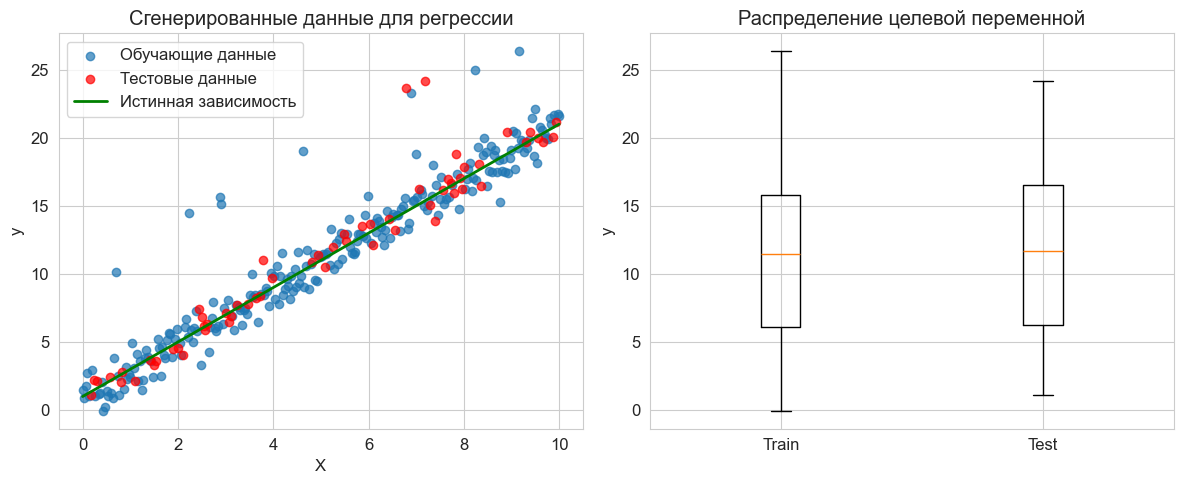

In [66]:
np.random.seed(42)
n_samples = 300

X = np.linspace(0, 10, n_samples).reshape(-1, 1)
true_y = 2 * X.squeeze() + 1
noise = np.random.normal(0, 1, n_samples)

outlier_indices = np.random.choice(n_samples, 10, replace=False)
noise[outlier_indices] += 8
y = true_y + noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
print(f" Размеры данных:")
print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.7, label='Обучающие данные')
plt.scatter(X_test, y_test, alpha=0.7, color='red', label='Тестовые данные')
plt.plot(X, true_y, 'g-', linewidth=2, label='Истинная зависимость')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Сгенерированные данные для регрессии')
plt.legend()
plt.subplot(1, 2, 2)
plt.boxplot([y_train, y_test], labels=['Train', 'Test'])
plt.title('Распределение целевой переменной')
plt.ylabel('y')
plt.tight_layout()
plt.show()


**Обучение и оценка качества моделей: сравнение Linear Regression, Ridge и Lasso по метрикам MSE, MAE и $R^2$.**

In [68]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1)
}

results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    
    results[name] = {
        'train_mse': mean_squared_error(y_train, y_pred_train),
        'test_mse': mean_squared_error(y_test, y_pred_test),
        'train_mae': mean_absolute_error(y_train, y_pred_train),
        'test_mae': mean_absolute_error(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test)
    }
    
    print(f"\n {name}:")
    print(f" MSE: train={results[name]['train_mse']:.3f}, test={results[name]['test_mse']:.3f}")
    print(f" MAE: train={results[name]['train_mae']:.3f}, test={results[name]['test_mae']:.3f}")
    print(f" R²:  train={results[name]['train_r2']:.3f}, test={results[name]['test_r2']:.3f}")


metrics_df = pd.DataFrame({
    name: [results[name]['test_mse'], 
           results[name]['test_mae'], 
           results[name]['test_r2']]
    for name in models.keys()
}, index=['MSE', 'MAE', 'R²'])

print("\n" + "="*50)
print("Сравнение метрик на тестовой выборке:")
print(metrics_df.round(3))



 Linear Regression:
 MSE: train=3.245, test=3.148
 MAE: train=1.077, test=0.898
 R²:  train=0.912, test=0.922

 Ridge (α=1.0):
 MSE: train=3.245, test=3.149
 MAE: train=1.077, test=0.899
 R²:  train=0.912, test=0.922

 Lasso (α=0.1):
 MSE: train=3.246, test=3.164
 MAE: train=1.079, test=0.902
 R²:  train=0.912, test=0.922

Сравнение метрик на тестовой выборке:
     Linear Regression  Ridge (α=1.0)  Lasso (α=0.1)
MSE              3.148          3.149          3.164
MAE              0.898          0.899          0.902
R²               0.922          0.922          0.922


**Оценка адекватности лучшей модели и визуализация распределения ошибок.**


 Дополнительные метрики для лучшей модели (Linear Regression):
MAPE: 10.07%
WAPE: 7.86%
Bad Frequency (ошибка > 3.0): 3.33%


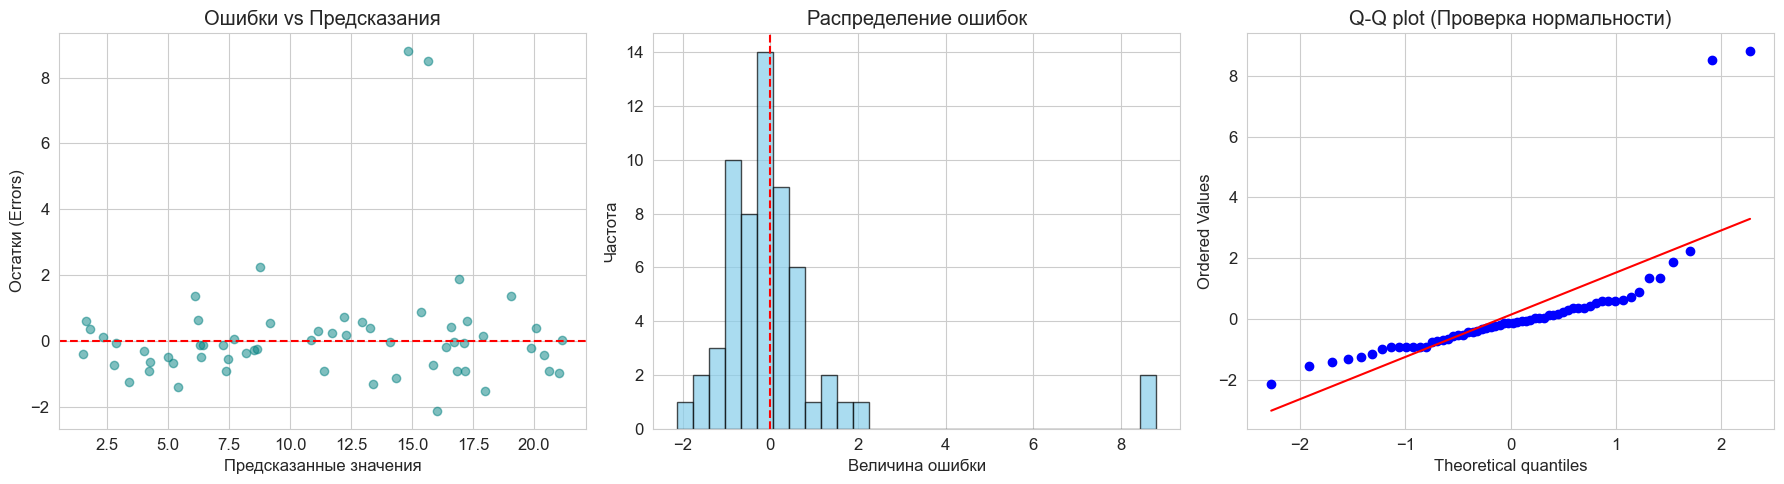

In [70]:
best_model_name = min(results.keys(), key=lambda x: results[x]['test_mse'])
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)


def mean_absolute_percentage_error(y_true, y_pred):
    
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-10))) * 100


def weighted_absolute_percentage_error(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def bad_frequency(y_true, y_pred, threshold=3.0):
    return np.mean(np.abs(y_true - y_pred) > threshold) * 100


mape = mean_absolute_percentage_error(y_test, y_pred)
wape = weighted_absolute_percentage_error(y_test, y_pred)
bad_freq = bad_frequency(y_test, y_pred, threshold=3.0)

print(f"\n Дополнительные метрики для лучшей модели ({best_model_name}):")
print(f"MAPE: {mape:.2f}%")
print(f"WAPE: {wape:.2f}%")
print(f"Bad Frequency (ошибка > 3.0): {bad_freq:.2f}%")


errors = y_test - y_pred

plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)
plt.scatter(y_pred, errors, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки (Errors)')
plt.title('Ошибки vs Предсказания')


plt.subplot(1, 3, 2)
plt.hist(errors, bins=30, alpha=0.7, edgecolor='black', color='skyblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Величина ошибки')
plt.ylabel('Частота')
plt.title('Распределение ошибок')


plt.subplot(1, 3, 3)
stats.probplot(errors, dist="norm", plot=plt)
plt.title('Q-Q plot (Проверка нормальности)')

plt.tight_layout()
plt.show()

**Генерация и подготовка синтетического набора данных для бинарной классификации.**

 Данные для классификации:
Размеры: (300, 2)
Баланс классов: [0.51333333 0.48666667]


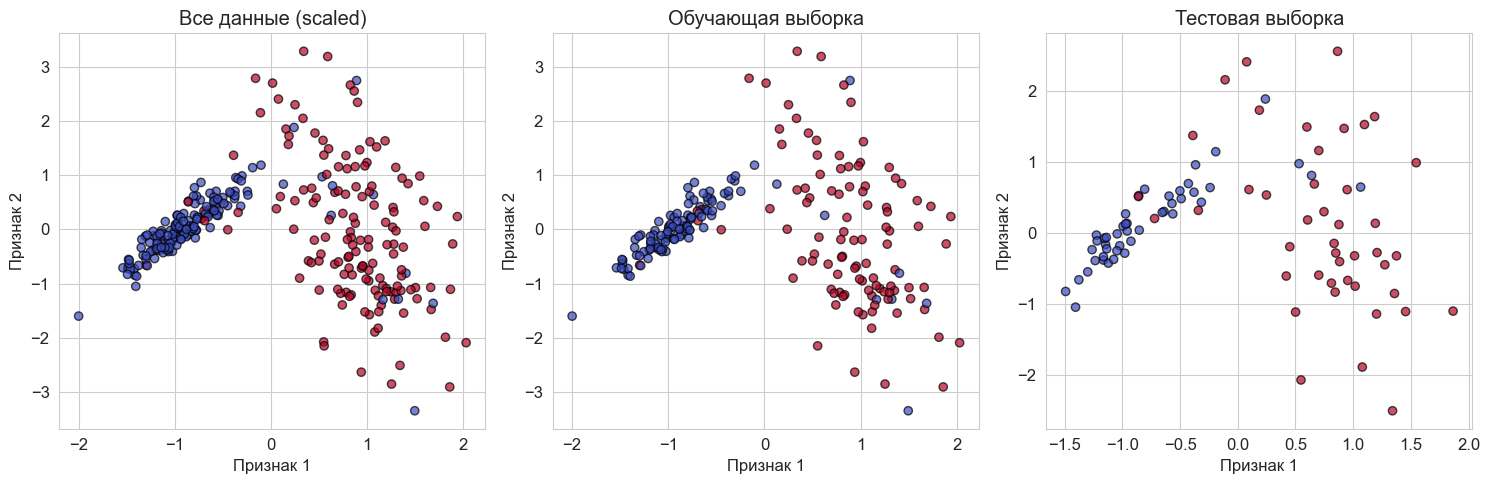

In [72]:
X_clf, y_clf = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    flip_y=0.1,
    random_state=42
)


scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)


X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

print(f" Данные для классификации:")
print(f"Размеры: {X_clf.shape}")
print(f"Баланс классов: {np.bincount(y_clf) / len(y_clf)}")


plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.scatter(X_clf_scaled[:, 0], X_clf_scaled[:, 1], c=y_clf, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Все данные (scaled)')


plt.subplot(1, 3, 2)
plt.scatter(X_train_clf[:, 0], X_train_clf[:, 1], c=y_train_clf, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Обучающая выборка')


plt.subplot(1, 3, 3)
plt.scatter(X_test_clf[:, 0], X_test_clf[:, 1], c=y_test_clf, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Тестовая выборка')

plt.tight_layout()
plt.show()

**Оценка качества классификации: вычисление метрик Accuracy, Precision, Recall и F1-score**

In [74]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Logistic Regression (L1)': LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
    'Logistic Regression (L2)': LogisticRegression(penalty='l2', random_state=42)
}

clf_results = {}

for name, clf in classifiers.items():
    # Обучение
    clf.fit(X_train_clf, y_train_clf)

    
    y_pred_clf = clf.predict(X_test_clf)
    y_pred_proba = clf.predict_proba(X_test_clf)[:, 1] # Вероятность положительного класса

   
    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    report = classification_report(y_test_clf, y_pred_clf, output_dict=True)

    clf_results[name] = {
        'accuracy': accuracy,
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'model': clf,
        'y_pred_proba': y_pred_proba
    }

    print(f"\n {name}:")
    print(f" Accuracy:  {accuracy:.3f}")
    print(f" F1-Score:  {report['weighted avg']['f1-score']:.3f}")


comparison_df = pd.DataFrame({
    name: [res['accuracy'], res['precision'], res['recall'], res['f1']]
    for name, res in clf_results.items()
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("\n" + "="*50)
print("Сравнение классификаторов:")
print(comparison_df.round(3).T)


 Logistic Regression:
 Accuracy:  0.911
 F1-Score:  0.911

 Logistic Regression (L1):
 Accuracy:  0.911
 F1-Score:  0.911

 Logistic Regression (L2):
 Accuracy:  0.911
 F1-Score:  0.911

Сравнение классификаторов:
                          Accuracy  Precision  Recall  F1-Score
Logistic Regression          0.911      0.911   0.911     0.911
Logistic Regression (L1)     0.911      0.911   0.911     0.911
Logistic Regression (L2)     0.911      0.911   0.911     0.911


C:\Users\yolff\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\yolff\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\yolff\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings

**Анализ качества классификации: решающие области, матрица ошибок и ROC-кривая**

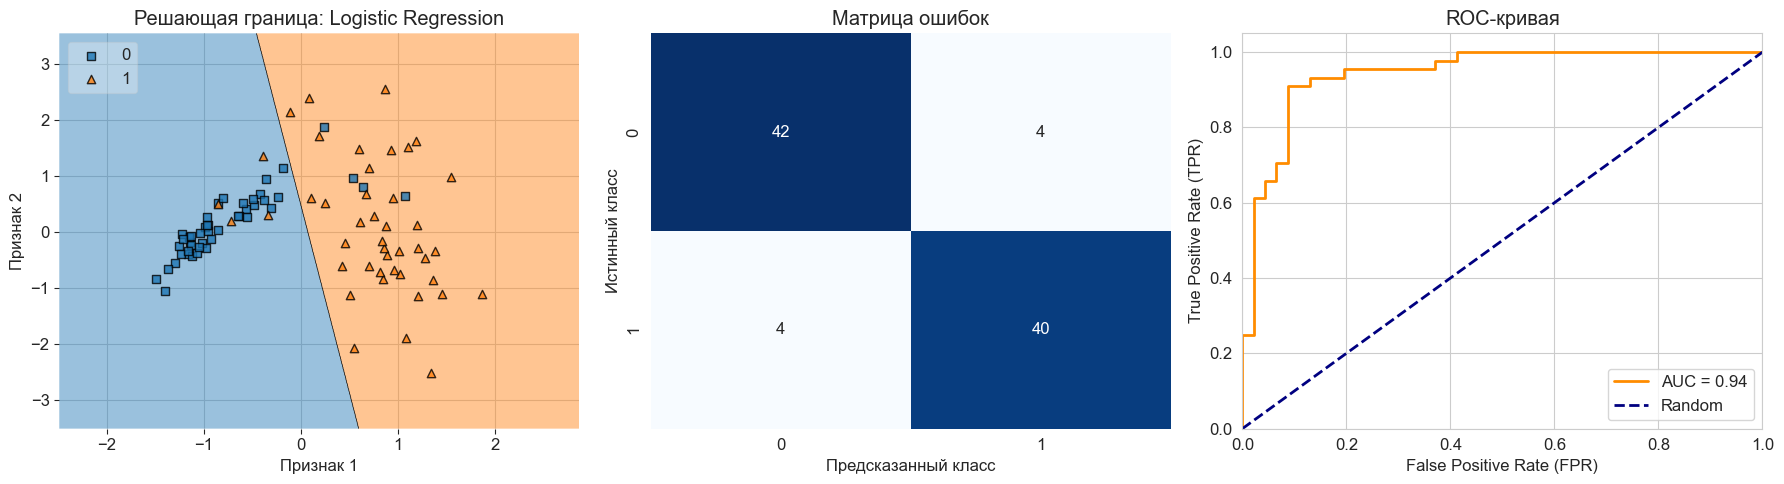

In [76]:
best_clf_name = max(clf_results.keys(), key=lambda x: clf_results[x]['accuracy'])
best_clf = clf_results[best_clf_name]['model']

plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)

plot_decision_regions(X_test_clf, y_test_clf, clf=best_clf, legend=2)
plt.title(f'Решающая граница: {best_clf_name}')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')


plt.subplot(1, 3, 2)
y_pred_best = best_clf.predict(X_test_clf)
cm = confusion_matrix(y_test_clf, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')


plt.subplot(1, 3, 3)
y_pred_proba = clf_results[best_clf_name]['y_pred_proba']
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Визуализация и исследование функций потерь: от 0-1 Loss до логистической и экспоненциальной.**

<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\c'
C:\Users\yolff\AppData\Local\Temp\ipykernel_13304\2737236150.py:34: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('Отступ (Margin) $M = y \cdot f(x)$', fontsize=12)


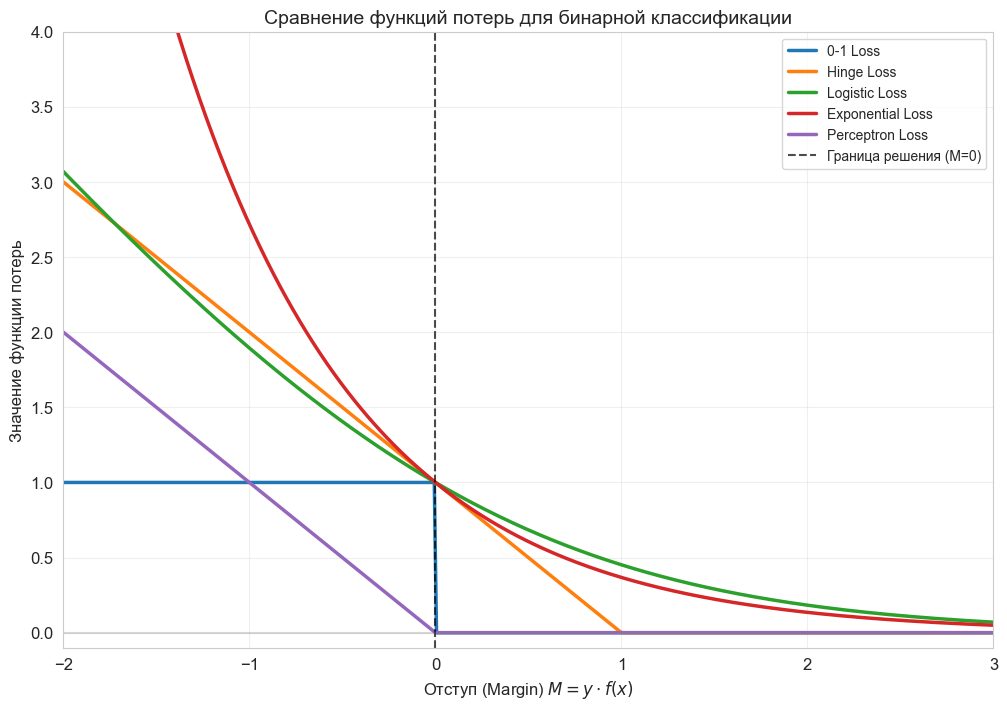

In [109]:
def exponential_loss(M):
    return np.exp(-M)

def perceptron_loss(M):
    return np.maximum(0, -M)

def hinge_loss(M):
    return np.maximum(0, 1 - M)

def logistic_loss(M):
    return np.log(1 + np.exp(-M)) / np.log(2) # нормализация log2 для масштаба

def zero_one_loss(M):
    return (M < 0).astype(float)


M = np.linspace(-3, 3, 500)

loss_functions = {
    '0-1 Loss': zero_one_loss(M),
    'Hinge Loss': hinge_loss(M),
    'Logistic Loss': logistic_loss(M),
    'Exponential Loss': exponential_loss(M),
    'Perceptron Loss': perceptron_loss(M)
}

plt.figure(figsize=(12, 8))
for name, loss in loss_functions.items():
    plt.plot(M, loss, label=name, linewidth=2.5)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.7, label='Граница решения (M=0)')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

plt.xlabel('Отступ (Margin) $M = y \cdot f(x)$', fontsize=12)
plt.ylabel('Значение функции потерь', fontsize=12)
plt.title('Сравнение функций потерь для бинарной классификации', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 4)
plt.xlim(-2, 3) 
plt.show()



**Применение логистической регрессии и линейного SVM на реальных данных: кросс-валидация и сравнительная оценка качества**


 Logistic (Log Loss):
CV Accuracy: 0.980 ± 0.015
Test Accuracy: 0.982
ROC AUC: 0.998

 Linear SVM (Hinge Loss):
CV Accuracy: 0.967 ± 0.017
Test Accuracy: 0.982
ROC AUC: 0.994


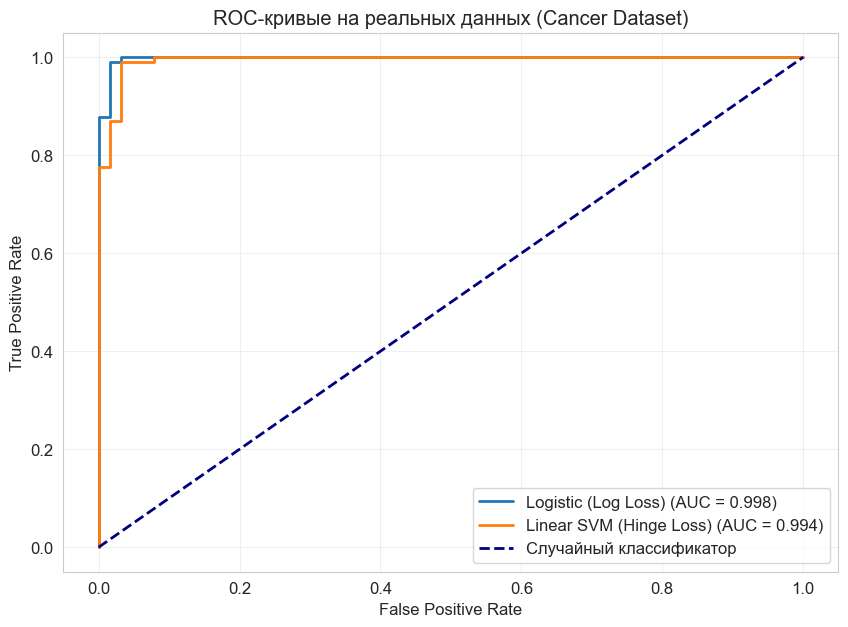

In [90]:
cancer_data = load_breast_cancer()
X_real, y_real = cancer_data.data, cancer_data.target


X_real_scaled = StandardScaler().fit_transform(X_real)

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real_scaled, y_real, test_size=0.3, random_state=42, stratify=y_real
)


real_classifiers = {
    'Logistic (Log Loss)': LogisticRegression(random_state=42, max_iter=1000),
    'Linear SVM (Hinge Loss)': SVC(kernel='linear', probability=True, random_state=42)
}

real_results = {}

for name, clf in real_classifiers.items():
  
    cv_scores = cross_val_score(clf, X_train_real, y_train_real, cv=5, scoring='accuracy')


    clf.fit(X_train_real, y_train_real)


    y_pred_real = clf.predict(X_test_real)
    y_pred_proba_real = clf.predict_proba(X_test_real)[:, 1]


    accuracy = accuracy_score(y_test_real, y_pred_real)
    fpr, tpr, _ = roc_curve(y_test_real, y_pred_proba_real)
    roc_auc = auc(fpr, tpr)

    real_results[name] = {
        'cv_mean': cv_scores.mean(),
        'test_accuracy': accuracy,
        'roc_auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr
    }

    print(f"\n {name}:")
    print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"Test Accuracy: {accuracy:.3f}")
    print(f"ROC AUC: {roc_auc:.3f}")


plt.figure(figsize=(10, 7))
for name, res in real_results.items():
    plt.plot(res['fpr'], res['tpr'], lw=2, label=f'{name} (AUC = {res["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые на реальных данных (Cancer Dataset)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

**Исследование интерпретируемости моделей: отбор признаков с помощью L1-регуляризации vs сжатие весов в L2.**

C:\Users\yolff\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\yolff\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\yolff\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings

 Анализ коэффициентов:
L1 (Lasso): ненулевых коэффициентов: 6 из 30
L2 (Ridge): ненулевых коэффициентов: 30 из 30


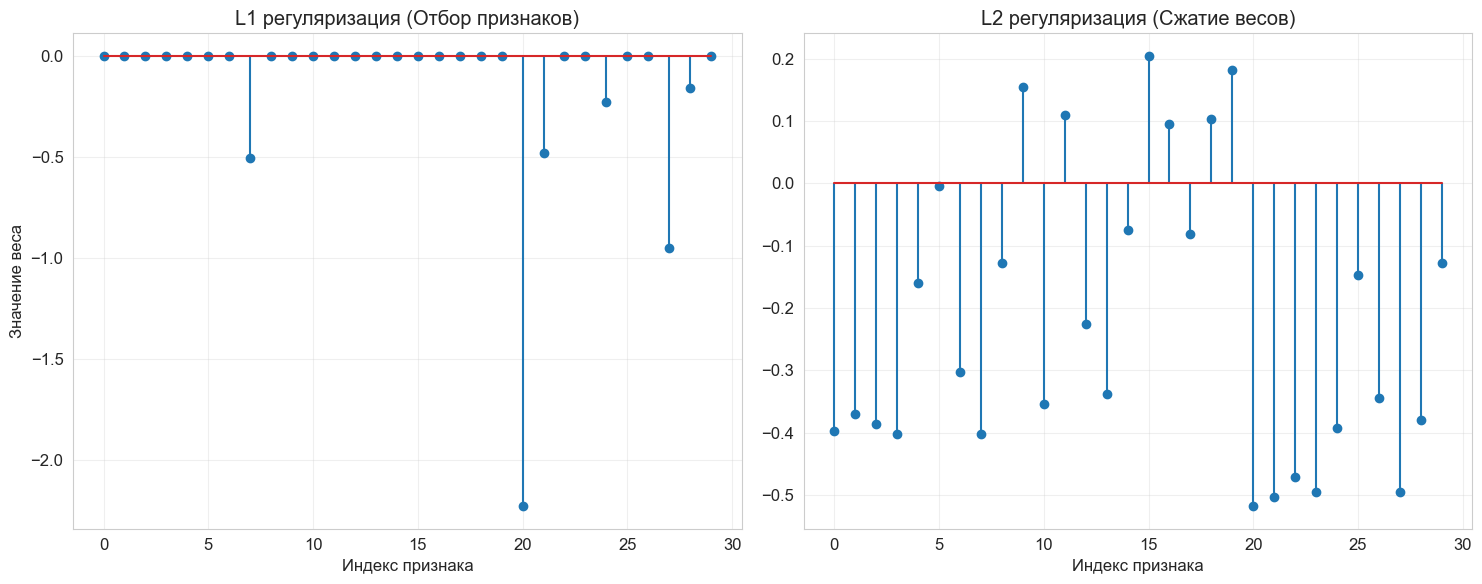


 Топ-5 признаков (по силе влияния в L1):
             Feature   L1_Coef
        worst radius -2.226347
worst concave points -0.951695
 mean concave points -0.504741
       worst texture -0.480091
    worst smoothness -0.227647


In [119]:

l1_model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42)
l2_model = LogisticRegression(penalty='l2', C=0.1, solver='liblinear', random_state=42)

l1_model.fit(X_train_real, y_train_real)
l2_model.fit(X_train_real, y_train_real)


l1_coef = l1_model.coef_[0]
l2_coef = l2_model.coef_[0]

print(" Анализ коэффициентов:")
print(f"L1 (Lasso): ненулевых коэффициентов: {np.sum(l1_coef != 0)} из {len(l1_coef)}")
print(f"L2 (Ridge): ненулевых коэффициентов: {np.sum(l2_coef != 0)} из {len(l2_coef)}")


plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)

plt.stem(range(len(l1_coef)), l1_coef)
plt.title('L1 регуляризация (Отбор признаков)')
plt.xlabel('Индекс признака')
plt.ylabel('Значение веса')
plt.grid(True, alpha=0.3)

# L2 график
plt.subplot(1, 2, 2)
plt.stem(range(len(l2_coef)), l2_coef)
plt.title('L2 регуляризация (Сжатие весов)')
plt.xlabel('Индекс признака')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


feature_importance = pd.DataFrame({
    'Feature': cancer_data.feature_names,
    'L1_Coef': l1_coef,
    'L2_Coef': l2_coef,
    'L1_Abs': np.abs(l1_coef)
})

print("\n Топ-5 признаков (по силе влияния в L1):")
print(feature_importance.nlargest(5, 'L1_Abs')[['Feature', 'L1_Coef']].to_string(index = False))

**Оценка качества прогнозирования спроса: расчет складских издержек и уровня сервиса**

Бизнес-метрики прогнозирования спроса:
 mse            : 95.72
 mae            : 7.81
 avg_overstock  : 3.95
 overstock_cost : 39,475 у.е.
 avg_stockout   : 3.86
 stockout_cost  : 77,275 у.е.
 total_cost     : 116,751 у.е.
 acceptable_rate: 70.1%


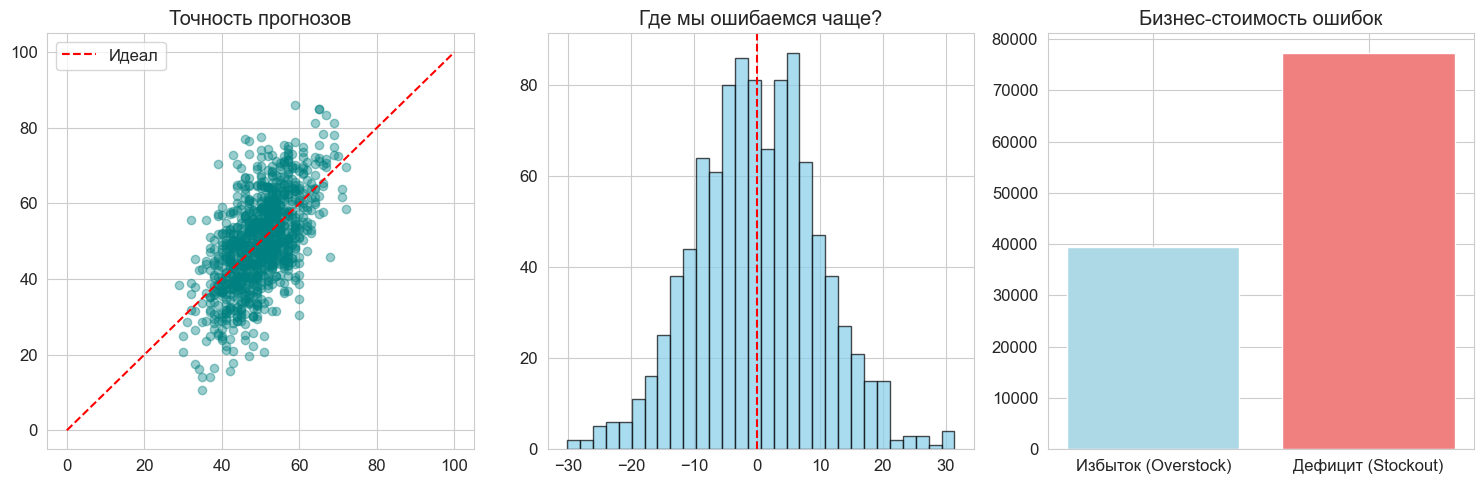

In [125]:

np.random.seed(42)
n_products = 1000


true_demand = np.random.poisson(50, n_products) 
predicted_demand = true_demand + np.random.normal(0, 10, n_products) 
predicted_demand = np.maximum(predicted_demand, 0)

def calculate_business_metrics(true, pred):
    metrics = {}
    metrics['mse'] = mean_squared_error(true, pred)
    metrics['mae'] = mean_absolute_error(true, pred)


    overstock = np.maximum(pred - true, 0)
    metrics['avg_overstock'] = np.mean(overstock)
    metrics['overstock_cost'] = np.sum(overstock) * 10 


    stockout = np.maximum(true - pred, 0)
    metrics['avg_stockout'] = np.mean(stockout)
    metrics['stockout_cost'] = np.sum(stockout) * 20 

    metrics['total_cost'] = metrics['overstock_cost'] + metrics['stockout_cost']

  
    acceptable_error = 0.2 
    acceptable_predictions = np.abs((true - pred) / np.maximum(true, 1)) <= acceptable_error
    metrics['acceptable_rate'] = np.mean(acceptable_predictions) * 100

    return metrics

business_metrics = calculate_business_metrics(true_demand, predicted_demand)


print("Бизнес-метрики прогнозирования спроса:")
for metric, value in business_metrics.items():
    if 'cost' in metric:
        print(f" {metric:15}: {value:,.0f} у.е.")
    elif 'rate' in metric:
        print(f" {metric:15}: {value:.1f}%")
    else:
        print(f" {metric:15}: {value:.2f}")


plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.scatter(true_demand, predicted_demand, alpha=0.4, color='teal')
plt.plot([0, 100], [0, 100], 'r--', label='Идеал')
plt.title('Точность прогнозов')
plt.legend()


plt.subplot(1, 3, 2)
errors = predicted_demand - true_demand
plt.hist(errors, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Где мы ошибаемся чаще?')


plt.subplot(1, 3, 3)
labels = ['Избыток (Overstock)', 'Дефицит (Stockout)']
costs = [business_metrics['overstock_cost'], business_metrics['stockout_cost']]
plt.bar(labels, costs, color=['lightblue', 'lightcoral'])
plt.title('Бизнес-стоимость ошибок')

plt.tight_layout()
plt.show()